# Sustainable Energy Data Analysis using K-Means Clustering

## Objective

The objective of this project is to analyse a sustainable energy dataset, preprocess the data, visualize important relationships, and apply the K-Means Clustering algorithm to group countries with similar energy characteristics.

The project includes data exploration, data cleaning, feature scaling, clustering, visualization and evaluation using the Elbow Method and Silhouette Score.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("global-data-on-sustainable-energy.csv")

df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


# Dataset Overview

This dataset contains sustainability and energy-related information collected from different countries.

It includes indicators such as electricity access, renewable energy generation, carbon emissions, GDP, and energy consumption.

The dataset is suitable for unsupervised learning because countries can be grouped based on similar energy and sustainability characteristics.

In [4]:
print("Dataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape
(3649, 21)

Column Names
Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 colum

# Dataset Understanding

### General Observations

- The dataset contains both numerical and categorical features.
- It provides information related to renewable energy, electricity access, GDP and carbon emissions.
- Some numerical columns contain missing values that require preprocessing.
- Countries with similar energy indicators can be grouped using K-Means Clustering.

# Data Cleaning and Missing Value Handling

Before applying K-Means Clustering, the dataset must be cleaned.

- The **Entity** column has no missing values.
- The **Density (P/Km2)** column contains one missing value and is converted into a numerical format.
- Numerical columns with missing values are filled using the **median** because it is less affected by outliers.
- This preprocessing prepares the dataset for clustering.

In [6]:
for col in df.select_dtypes(include="object").columns:
    if col != "Entity":
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values in numeric columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renewable-electricity-generating-capacity-per-capita                0
Financial flows to developing countries (US $)                      0
Renewable energy share in the total final energy consumption (%)    0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
Value_co2_emissions_kt_by_country                           

# Data Visualization

Before applying K-Means Clustering, it is useful to visualize the numerical features to understand their distribution and relationships.

The following plots help identify patterns, outliers, and possible clusters in the dataset.

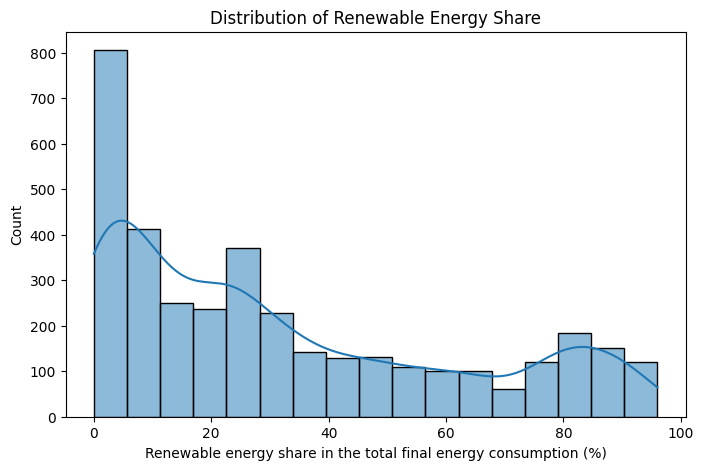

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Renewable energy share in the total final energy consumption (%)"], kde=True)

plt.title("Distribution of Renewable Energy Share")

plt.show()

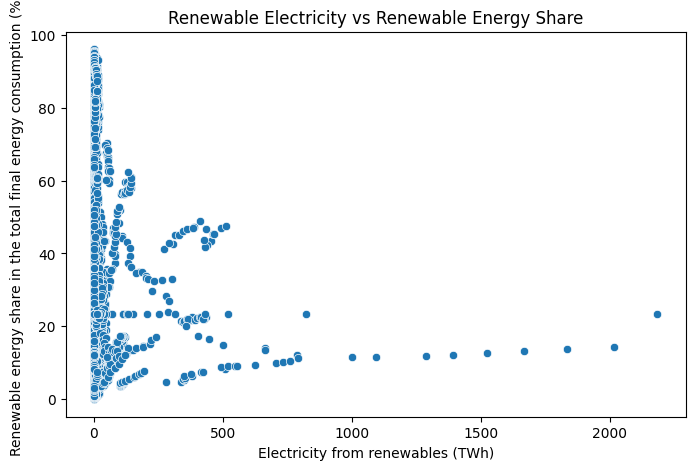

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Electricity from renewables (TWh)",
    y="Renewable energy share in the total final energy consumption (%)"
)

plt.title("Renewable Electricity vs Renewable Energy Share")

plt.show()

   Year  Access to electricity (% of population)  \
0  2000                                 1.613591   
1  2001                                 4.074574   
2  2002                                 9.409158   
3  2003                                14.738506   
4  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               7.75      

   Financial flows to developing countries (US $)  \
0                                     

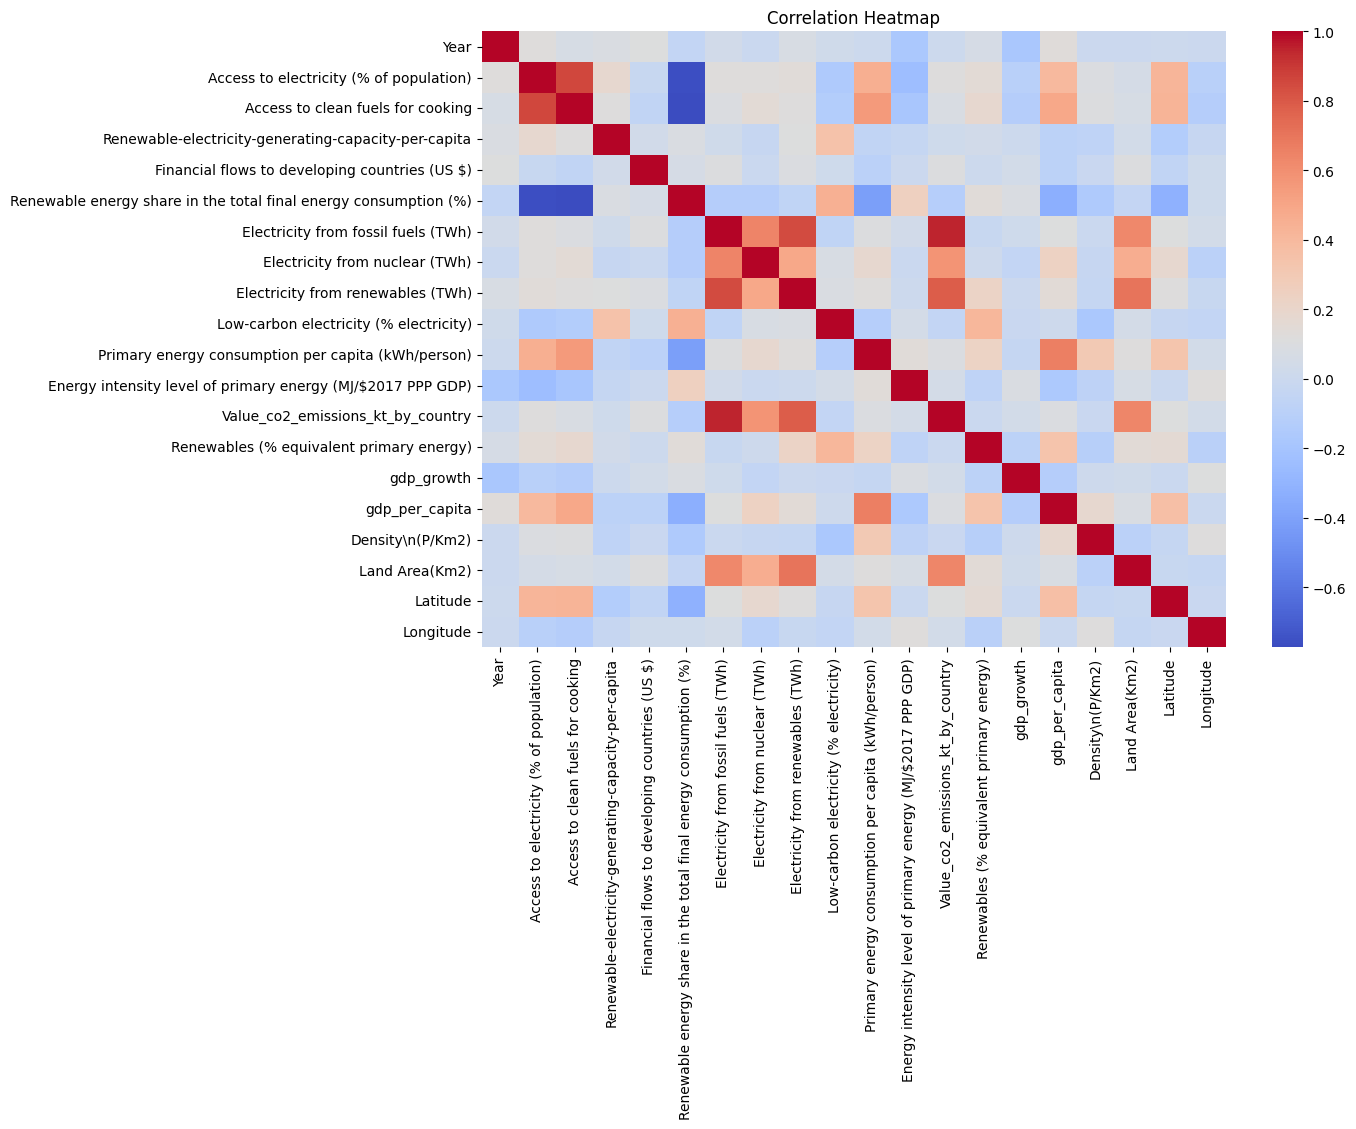

In [10]:
# Select only numerical columns
X = df.select_dtypes(include=["int64", "float64"])

print(X.head())

plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Feature Scaling

K-Means Clustering is distance-based, so feature scaling is necessary to ensure that all numerical features contribute equally during clustering.

StandardScaler is used to standardize the numerical features.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.65830257 -2.55805635 -1.51170233 -0.39072391 -0.21780016  0.44060607
  -0.20117982 -0.18094341 -0.2259541   0.85739947 -0.7317376  -1.0501535
  -0.19439441 -0.23487386  0.01987211 -0.42115428 -0.23933936  0.01208613
   0.64974376  0.79731755]
 [-1.49310612 -2.47669329 -1.48562801 -0.39240951 -0.21724947  0.46152477
  -0.20138152 -0.18094341 -0.22412945  1.40796642 -0.73362733 -1.02106499
  -0.1944356  -0.23487386  0.01987211 -0.42115428 -0.23933936  0.01208613
   0.64974376  0.79731755]
 [-1.32790966 -2.30032551 -1.4595537  -0.39423558 -0.19812542  0.19506859
  -0.20126626 -0.18094341 -0.22355325  1.30287343 -0.73437599 -1.11996593
  -0.19402371 -0.23487386  0.01987211 -0.65181334 -0.23933936  0.01208613
   0.64974376  0.79731755]
 [-1.16271321 -2.12413083 -1.4256571  -0.39601482 -0.08788677  0.15494584
  -0.20074759 -0.18094341 -0.22288101  0.88857389 -0.73382647 -1.11996593
  -0.19376285 -0.23487386  0.99024759 -0.6512231  -0.23933936  0.01208613
   0.64974376  0.79731755]
 [-0.

# Elbow Method

The Elbow Method helps determine the optimal number of clusters (K).

The Within-Cluster Sum of Squares (WCSS) is calculated for different values of K. The point where the decrease in WCSS begins to slow down is selected as the optimal number of clusters.

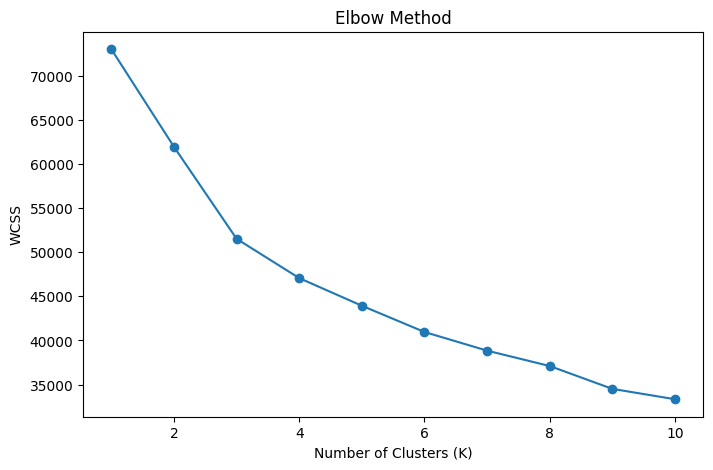

In [12]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# K-Means Clustering

Based on the Elbow Method, the optimal number of clusters is selected as **3**.

The K-Means algorithm groups countries with similar sustainable energy characteristics into three clusters.

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[["Entity", "Cluster"]].head(10))

        Entity  Cluster
0  Afghanistan        2
1  Afghanistan        2
2  Afghanistan        2
3  Afghanistan        2
4  Afghanistan        2
5  Afghanistan        2
6  Afghanistan        2
7  Afghanistan        2
8  Afghanistan        2
9  Afghanistan        2


In [14]:
print(df["Cluster"].value_counts())

Cluster
1    2336
2    1274
0      39
Name: count, dtype: int64


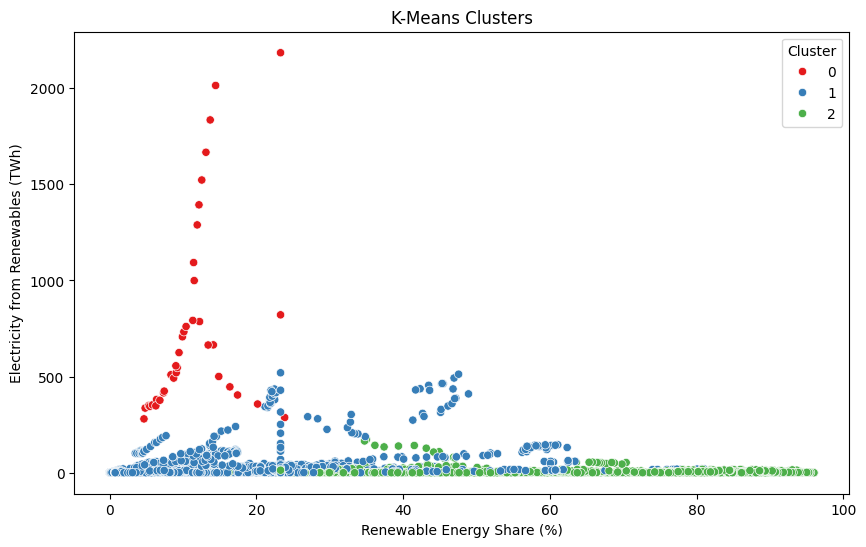

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Renewable energy share in the total final energy consumption (%)"],
    y=df["Electricity from renewables (TWh)"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("K-Means Clusters")

plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Electricity from Renewables (TWh)")

plt.show()

## Cluster Evaluation

The K-Means model achieved a **Silhouette Score of approximately 0.20**.

This indicates that the clusters are moderately separated, with some overlap between groups. Since the dataset contains many countries with similar sustainability and energy characteristics, a lower silhouette score is expected. Despite this, the clustering still provides meaningful grouping of countries based on their energy and environmental indicators.

In [16]:
score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.2037828506485809


In [17]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

print(centers)

       Year  Access to electricity (% of population)  \
0  0.108029                                 0.685221   
1  0.052853                                 0.610479   
2 -0.100217                                -1.140347   

   Access to clean fuels for cooking  \
0                           0.455772   
1                           0.658489   
2                          -1.221354   

   Renewable-electricity-generating-capacity-per-capita  \
0                                           0.207999      
1                                           0.078911      
2                                          -0.151058      

   Financial flows to developing countries (US $)  \
0                                        0.260164   
1                                       -0.043447   
2                                        0.071699   

   Renewable energy share in the total final energy consumption (%)  \
0                                          -0.713809                  
1                     

# Final Insights

## Project Summary

- The sustainable energy dataset was successfully analysed and preprocessed.
- Missing values in numerical columns were handled using the median.
- The categorical **Entity** column was excluded from clustering because K-Means requires numerical data.
- Numerical features were standardized using **StandardScaler**.
- The Elbow Method suggested **3 clusters**, which were used to group countries with similar sustainability characteristics.
- The clustering results were visualized using scatter plots.
- The Silhouette Score was calculated to evaluate the clustering quality.

## Conclusion

The K-Means Clustering algorithm successfully grouped countries based on their energy production, renewable energy usage, electricity access, GDP, and environmental indicators. The obtained **Silhouette Score of 0.20** indicates moderate cluster separation, which is reasonable for a real-world sustainability dataset with overlapping characteristics. The clustering provides useful insights for comparing countries and understanding global sustainable energy patterns.